**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [3]:
df = pd.read_csv('big_sales_data.csv')
df

,order_id,product,category,price,quantity,date
0,1,Bag,Accessories,2360,3,2023-04-17
1,2,Shoes,Clothing,3638,2,2024-04-11
2,3,Bag,Accessories,1830,3,2023-03-29
3,4,Shoes,Clothing,4919,4,2023-05-11
4,5,Watch,Accessories,3769,4,2024-05-06
...,...,...,...,...,...,...
995,996,Bag,Accessories,3611,3,2023-04-27
996,997,Phone,Electronics,23458,2,2024-11-15
997,998,Bag,Accessories,3793,1,2024-01-30
998,999,Bag,Accessories,1975,1,2023-07-03


In [4]:
df.head()

,order_id,product,category,price,quantity,date
0,1,Bag,Accessories,2360,3,2023-04-17
1,2,Shoes,Clothing,3638,2,2024-04-11
2,3,Bag,Accessories,1830,3,2023-03-29
3,4,Shoes,Clothing,4919,4,2023-05-11
4,5,Watch,Accessories,3769,4,2024-05-06


In [5]:
df.shape # shows rows and columns 

(1000, 6)

In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  1000 non-null   int64 
 1   product   1000 non-null   object
 2   category  1000 non-null   object
 3   price     1000 non-null   int64 
 4   quantity  1000 non-null   int64 
 5   date      1000 non-null   object
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [37]:
df.describe() # statistics details 

,order_id,price,quantity,date,total_sales,month,year
count,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000
mean,500.500000,14094.576000,2.500000,2024-01-04 09:28:48.000000256,34396.193000,6.501000,2023.511000
min,1.000000,801.000000,1.000000,2023-01-01 00:00:00,801.000000,1.000000,2023.000000
25%,250.750000,2257.000000,1.000000,2023-07-06 18:00:00,4634.250000,4.000000,2023.000000
50%,500.500000,3776.500000,3.000000,2024-01-08 12:00:00,9997.000000,6.000000,2024.000000
75%,750.250000,19317.250000,4.000000,2024-07-01 00:00:00,33356.000000,10.000000,2024.000000
max,1000.000000,69557.000000,4.000000,2024-12-31 00:00:00,277864.000000,12.000000,2024.000000
std,288.819436,19684.135686,1.134587,NaN,55176.061196,3.490585,0.500129


# Data Cleaning

In [8]:
df.isnull().sum()

order_id    0
product     0
category    0
price       0
quantity    0
date        0
dtype: int64

In [9]:
df.dropna(inplace = True)

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df['date']

0     2023-04-17
1     2024-04-11
2     2023-03-29
3     2023-05-11
4     2024-05-06
         ...    
995   2023-04-27
996   2024-11-15
997   2024-01-30
998   2023-07-03
999   2024-06-07
Name: date, Length: 1000, dtype: datetime64[ns]

# Feature Engineering

In [38]:
df['total_sales'] = df['price'] * df['quantity']
df['total_sales']

0       7080
1       7276
2       5490
3      19676
4      15076
       ...  
995    10833
996    46916
997     3793
998     1975
999     2714
Name: total_sales, Length: 1000, dtype: int64

In [39]:
df['month'] = df['date'].dt.month
df['month']

0       4
1       4
2       3
3       5
4       5
       ..
995     4
996    11
997     1
998     7
999     6
Name: month, Length: 1000, dtype: int32

In [40]:
df['year'] = df['date'].dt.year
df['year']

0      2023
1      2024
2      2023
3      2023
4      2024
       ... 
995    2023
996    2024
997    2024
998    2023
999    2024
Name: year, Length: 1000, dtype: int32

# Data Analysis

**Total Revenue**

In [19]:
total_revenue = df['total_sales'].sum()
print(total_revenue)

34396193


**Sales by Product**

In [26]:
product_sales = df.groupby('product')['total_sales'].sum().sort_values(ascending = False)
print(product_sales)

product
Laptop        21164372
Phone          7534494
Watch          2123603
Shoes          1216322
Bag            1055526
Headphones      806712
Shirt           495164
Name: total_sales, dtype: int64


**Sales by Category**

In [27]:
category_sales =df.groupby('category')['total_sales'].sum()
print(category_sales)

category
Accessories     3179129
Clothing        1711486
Electronics    29505578
Name: total_sales, dtype: int64


**Monthly Sales Trend** 

In [28]:
monthly_sales = df.groupby('month')['total_sales'].sum()
print(monthly_sales)

month
1     3619675
2     2915636
3     2656914
4     3110960
5     2471679
6     2361709
7     2455703
8     2815630
9     2955507
10    4131007
11    2426719
12    2475054
Name: total_sales, dtype: int64


**Yearly Growth**

In [29]:
yearly_sales = df.groupby('year')['total_sales'].sum()
print(yearly_sales)

year
2023    16359517
2024    18036676
Name: total_sales, dtype: int64


# Visualization

**Monthly Trend (Line Chart)**

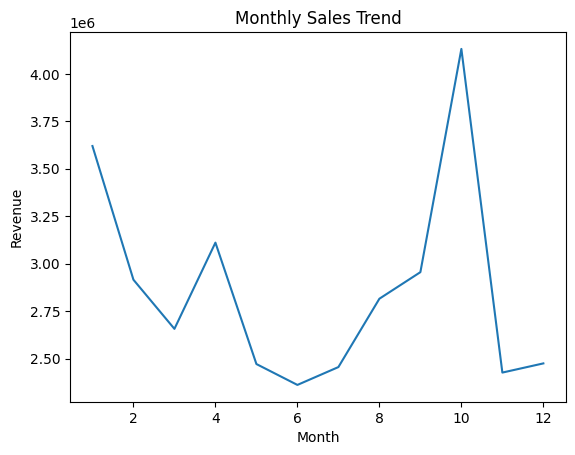

In [32]:
monthly_sales.plot(kind = 'line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

**Product Performance (Bar Chart)**

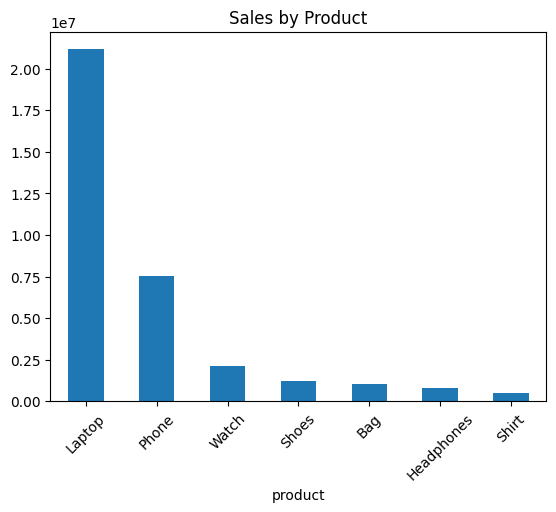

In [33]:
product_sales.plot(kind = 'bar')
plt.title("Sales by Product")
plt.xticks(rotation = 45)
plt.show()

**Category Comparison (Seaborn)**

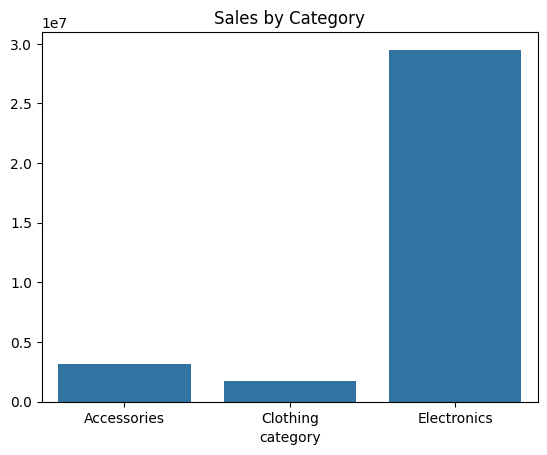

In [35]:
sns.barplot(x = category_sales.index, y = category_sales.values)
plt.title("Sales by Category")
plt.show()